In [1]:
# ETL VisionGuard - Cangurera Inteligente
# Extraccion de Conocimiento en Bases de Datos (KDD) - IDGS 901
# Maestro: MTI. Juan Antonio Leon Lopez
#
# Pipeline ETL del proyecto VisionGuard. El pipeline consulta directo la
# base de datos (cangurera_local) en vez de regenerar un mock en memoria
# cada vez que se corre -- el mock v5 ya esta insertado de verdad (ver
# 
# ), asi que se trata como si fuera data real. La
# generacion de mock/grafo se movio a un archivo aparte
# (generador_datos_mock.ipynb), para cuando se necesite producir mas
# datos de prueba en el futuro.

# 1. Importamos las librerías necesarias
import pandas as pd
import pyodbc
from datetime import datetime, date, timedelta
import math
import numpy as np
from sklearn.cluster import DBSCAN
import json

print("Librerias importadas.")

Librerias importadas.


In [2]:
# ============================================================
# Fase 1 -- Seleccion de datos (Extraccion)
# ============================================================

# 2. Configuracion de conexion a SQL Server
CONFIG_DB = {
    "servidor": "db57112.public.databaseasp.net",
    "base_datos": "db57112",
    "usuario": "db57112",
    "password": "C%x48dN_L5@s",
    "driver": "{ODBC Driver 17 for SQL Server}"
}

def construir_cadena_conexion(config):
    return (
        f"DRIVER={config['driver']};"
        f"SERVER={config['servidor']};"
        f"DATABASE={config['base_datos']};"
        f"UID={config['usuario']};"
        f"PWD={config['password']};"
    )

print("Configuración de conexión lista.")

Configuración de conexión lista.


In [3]:
# 3. Rango de fechas del periodo de consultoria
fecha_inicio = date(2026, 7, 1)
fecha_fin    = date(2026, 7, 31)
print(f"Rango de extracción definido: {fecha_inicio} a {fecha_fin}")

Rango de extracción definido: 2026-07-01 a 2026-07-31


In [4]:
# 4. Funcion de extraccion de eventos
# FIX: esquema Operativo explicito, columna real TimestampEvento (no
# fecha_evento), y limite superior +1 dia para no perder eventos ocurridos
# despues de medianoche del ultimo dia del rango.
def extraer_eventos_detectados(config, fecha_inicio, fecha_fin):
    cadena = construir_cadena_conexion(config)
    query = """
        SELECT Id, RecorridoId, TipoEventoId, TimestampEvento,
               Latitud, Longitud, Geo_Es_Estimado, FuerzaImpactoG,
               DistanciaCm, IrIzquierdo, IrDerecho
        FROM Operativo.Eventos_Detectados
        WHERE TimestampEvento >= ? AND TimestampEvento < DATEADD(day, 1, ?)
    """
    with pyodbc.connect(cadena) as conexion:
        df = pd.read_sql(query, conexion, params=[fecha_inicio, fecha_fin])
    # Renombrar a los nombres que usa el resto del pipeline (snake_case)
    df = df.rename(columns={
        "TipoEventoId": "tipo_evento_id",
        "RecorridoId": "recorrido_id",
    })
    print(f"Eventos extraidos de la BD: {len(df)} (rango {fecha_inicio} a {fecha_fin})")
    return df

# 4b. Extraccion de coordenadas de recorridos reales -- reemplaza al mock
def extraer_recorridos_coordenadas(config, fecha_inicio, fecha_fin):
    # Extrae los recorridos y sus puntos GPS reales, en la MISMA forma que
    # el generador de mock producia en memoria:
    # [{"recorrido_id": ..., "coordenadas": [{"lat","lon","timestamp"}, ...]}]
    # Esto permite que contar_recorridos_por_zona() / calcular_iaz() sigan
    # funcionando sin ningun cambio, sea el origen mock o BD real.
    cadena = construir_cadena_conexion(config)
    query = """
        SELECT rc.RecorridoId, rc.Latitud, rc.Longitud, rc.Fecha
        FROM Operativo.RecorridoCoordenadas rc
        JOIN Operativo.Recorridos r ON rc.RecorridoId = r.Id
        WHERE r.FechaInicio >= ? AND r.FechaInicio < DATEADD(day, 1, ?)
        ORDER BY rc.RecorridoId, rc.Fecha
    """
    with pyodbc.connect(cadena) as conexion:
        df = pd.read_sql(query, conexion, params=[fecha_inicio, fecha_fin])

    recorridos = []
    for recorrido_id, grupo in df.groupby("RecorridoId"):
        coordenadas = [
            {"lat": float(fila["Latitud"]), "lon": float(fila["Longitud"]), "timestamp": fila["Fecha"]}
            for _, fila in grupo.iterrows()
        ]
        recorridos.append({"recorrido_id": int(recorrido_id), "coordenadas": coordenadas})

    print(f"Recorridos extraidos de la BD: {len(recorridos)} (rango {fecha_inicio} a {fecha_fin})")
    return recorridos

print("Funciones de extraccion real definidas.")

Funciones de extraccion real definidas.


In [5]:
# ============================================================
# Fase 2 -- Preprocesamiento (limpieza y transformacion)
# Aqui se limpian los datos y se crea la variable derivada IAZ.
# ============================================================

# 5. Clustering de zonas calientes (DBSCAN sobre coordenadas de eventos)
RADIO_ZONA_METROS = 12
MIN_EVENTOS_POR_ZONA = 3
RADIO_TIERRA_METROS = 6371000

def _distancia_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def clusterizar_zonas(df_eventos, eps_metros=RADIO_ZONA_METROS, min_samples=MIN_EVENTOS_POR_ZONA):
    df = df_eventos.dropna(subset=["Latitud", "Longitud"]).copy()
    coords_rad = np.radians(df[["Latitud", "Longitud"]].astype(float).values)
    eps_rad = eps_metros / RADIO_TIERRA_METROS
    modelo = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
    df["zona_id"] = modelo.fit_predict(coords_rad)
    n_zonas = df[df["zona_id"] != -1]["zona_id"].nunique()
    n_ruido = (df["zona_id"] == -1).sum()
    print(f"Zonas detectadas: {n_zonas} | Eventos clasificados como ruido (sin zona): {n_ruido}")
    return df

In [6]:
# Extraccion real desde la BD (reemplaza al generador de mock)
df_eventos = extraer_eventos_detectados(CONFIG_DB, fecha_inicio, fecha_fin)
recorridos_mock = extraer_recorridos_coordenadas(CONFIG_DB, fecha_inicio, fecha_fin)
df_eventos_zonificados = clusterizar_zonas(df_eventos)

C:\Users\mushr\AppData\Local\Temp\ipykernel_14444\2401357505.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion, params=[fecha_inicio, fecha_fin])


Eventos extraidos de la BD: 98 (rango 2026-07-01 a 2026-07-31)


C:\Users\mushr\AppData\Local\Temp\ipykernel_14444\2401357505.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion, params=[fecha_inicio, fecha_fin])


Recorridos extraidos de la BD: 45 (rango 2026-07-01 a 2026-07-31)
Zonas detectadas: 10 | Eventos clasificados como ruido (sin zona): 0


In [7]:
# ============================================================
# Fase 3 -- Mineria de datos (alcance academico, aislado del IAZ real)
# Pieza independiente del pipeline real: mock propio (no eventos_mock/
# recorridos_mock) sobre columnas de sensor que existen en
# Operativo.Eventos_Detectados pero nunca se usan (FuerzaImpactoG,
# DistanciaCm, IrIzquierdo, IrDerecho). Entrena un DecisionTreeClassifier
# para predecir Severidad. Cubre la categoria "clasificacion" de la
# rubrica KDD sin repetir el clustering ya usado en el IAZ (DBSCAN).
# ============================================================

# 12. Mock académico — lecturas simuladas de sensor
np.random.seed(42)
N_MUESTRAS = 200

fuerza_impacto_g = np.random.uniform(0.1, 4.0, N_MUESTRAS)
distancia_cm = np.random.uniform(5, 150, N_MUESTRAS)
ir_izquierdo = np.random.randint(0, 2, N_MUESTRAS)
ir_derecho = np.random.randint(0, 2, N_MUESTRAS)

df_sensor = pd.DataFrame({
    "FuerzaImpactoG": fuerza_impacto_g,
    "DistanciaCm": distancia_cm,
    "IrIzquierdo": ir_izquierdo,
    "IrDerecho": ir_derecho,
})

condiciones = [
    (df_sensor["FuerzaImpactoG"] >= 2.5) & (df_sensor["DistanciaCm"] <= 40),
    (df_sensor["FuerzaImpactoG"] >= 1.2) | (df_sensor["DistanciaCm"] <= 70),
]
etiquetas = ["Critica", "Media"]
df_sensor["Severidad"] = np.select(condiciones, etiquetas, default="Baja")

print(df_sensor["Severidad"].value_counts())
print(df_sensor.head())

Severidad
Media      145
Baja        40
Critica     15
Name: count, dtype: int64
   FuerzaImpactoG  DistanciaCm  IrIzquierdo  IrDerecho Severidad
0        1.560706    98.094589            0          1     Media
1        3.807786    17.200295            1          0   Critica
2        2.954776    28.436164            0          0   Critica
3        2.434768   135.290357            0          0     Media
4        0.708473    92.932214            1          0      Baja


Exactitud del modelo: 96.67%


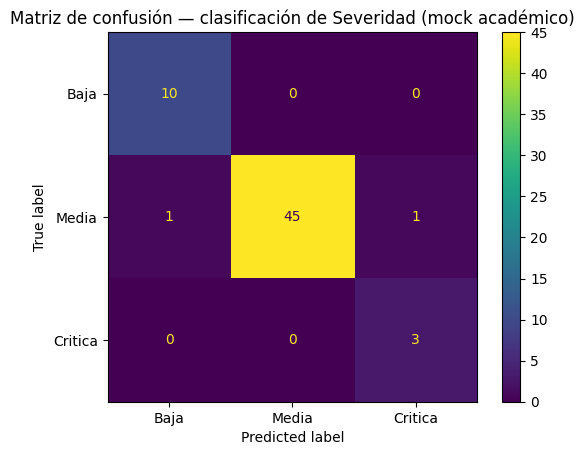

In [8]:
# 13. Entrenamiento del DecisionTreeClassifier (con grafica para entrega a Leon)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df_sensor[["FuerzaImpactoG", "DistanciaCm", "IrIzquierdo", "IrDerecho"]]
y = df_sensor["Severidad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo_arbol = DecisionTreeClassifier(random_state=42, max_depth=4)
modelo_arbol.fit(X_train, y_train)

y_pred = modelo_arbol.predict(X_test)
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {exactitud:.2%}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["Baja", "Media", "Critica"]
)
plt.title("Matriz de confusión — clasificación de Severidad (mock académico)")
plt.show()

In [9]:
# ============================================================
# Fase 4 -- Interpretacion / Evaluacion (calculo del IAZ)
# El IAZ se calcula aqui como variable derivada. Incluye
# Latitud_Centro/Longitud_Centro de cada zona, necesarios para poblar
# Analitico.Zonas_IAZ en la Fase 5.
# ============================================================

# 10. Cálculo del IAZ por zona
PESO_SEVERIDAD = {"Baja": 1, "Media": 3, "Critica": 5}
MAPA_SEVERIDAD_POR_TIPO = {2: "Baja", 5: "Media", 4: "Critica"}

def calcular_centros_zonas(df_zonificado):
    zonas_validas = df_zonificado[df_zonificado["zona_id"] != -1]
    return zonas_validas.groupby("zona_id")[["Latitud", "Longitud"]].mean()

def contar_recorridos_por_zona(centros_zonas, recorridos, radio_metros=RADIO_ZONA_METROS):
    conteo = {zona_id: 0 for zona_id in centros_zonas.index}
    for recorrido in recorridos:
        zonas_cruzadas = set()
        for punto in recorrido["coordenadas"]:
            for zona_id, centro in centros_zonas.iterrows():
                if zona_id in zonas_cruzadas:
                    continue
                d = _distancia_m(punto["lat"], punto["lon"], centro["Latitud"], centro["Longitud"])
                if d <= radio_metros:
                    zonas_cruzadas.add(zona_id)
        for zona_id in zonas_cruzadas:
            conteo[zona_id] += 1
    return conteo

def calcular_iaz(df_zonificado, recorridos, radio_metros=RADIO_ZONA_METROS):
    df = df_zonificado.copy()
    df["severidad"] = df["tipo_evento_id"].map(MAPA_SEVERIDAD_POR_TIPO)
    df["peso"] = df["severidad"].map(PESO_SEVERIDAD)
    suma_pesos = df[df["zona_id"] != -1].groupby("zona_id")["peso"].sum()
    centros_zonas = calcular_centros_zonas(df)
    recorridos_por_zona = contar_recorridos_por_zona(centros_zonas, recorridos, radio_metros)
    resultados = []
    for zona_id in suma_pesos.index:
        n_recorridos = recorridos_por_zona.get(zona_id, 0)
        iaz = suma_pesos[zona_id] / n_recorridos if n_recorridos > 0 else None
        centro = centros_zonas.loc[zona_id]
        resultados.append({
            "zona_id": zona_id,
            "Latitud_Centro": centro["Latitud"],
            "Longitud_Centro": centro["Longitud"],
            "suma_severidad": suma_pesos[zona_id],
            "recorridos_que_cruzaron": n_recorridos,
            "iaz": iaz,
        })
    return pd.DataFrame(resultados).sort_values("iaz", ascending=False)

df_iaz = calcular_iaz(df_eventos_zonificados, recorridos_mock)
print(df_iaz)

   zona_id  Latitud_Centro  Longitud_Centro  suma_severidad  \
1        1       21.063280      -101.579521              36   
0        0       21.062358      -101.579416              31   
8        8       21.062932      -101.581577              40   
2        2       21.064193      -101.583081              39   
9        9       21.063371      -101.581913              27   
6        6       21.062981      -101.580493              21   
3        3       21.062635      -101.578254              12   
5        5       21.062316      -101.578194              24   
4        4       21.063579      -101.581278               7   
7        7       21.063329      -101.581575              33   

   recorridos_que_cruzaron        iaz  
1                        3  12.000000  
0                        3  10.333333  
8                        6   6.666667  
2                        6   6.500000  
9                        6   4.500000  
6                        5   4.200000  
3                        3

In [10]:
# 10c. Clasificacion de accesibilidad por zona
# Umbrales fijos anclados a la escala de pesos de severidad (Baja=1,
# Media=3, Critica=5). No se persiste en Zonas_IAZ -- se calcula al vuelo
# en consumo (backend/frontend), decision confirmada en ticket 004.2.
def clasificar_accesibilidad(iaz):
    if iaz is None:
        return None
    if iaz < 3:
        return "Alta"
    elif iaz < 6:
        return "Media"
    else:
        return "Baja"

df_iaz["nivel_accesibilidad"] = df_iaz["iaz"].apply(clasificar_accesibilidad)
print(df_iaz[["zona_id", "iaz", "nivel_accesibilidad"]])

   zona_id        iaz nivel_accesibilidad
1        1  12.000000                Baja
0        0  10.333333                Baja
8        8   6.666667                Baja
2        2   6.500000                Baja
9        9   4.500000               Media
6        6   4.200000               Media
3        3   4.000000               Media
5        5   4.000000               Media
4        4   3.500000               Media
7        7   2.750000                Alta


In [11]:
# 10d. Generacion del JSON de zonas (contrato ZonaAccesibilidad, ticket 005)
MAPA_TIPO_EVENTO = {2: "Obstaculo", 5: "Tropiezo", 4: "Caida_Detectada"}

def generar_json_zonas(df_iaz, df_eventos_zonificados, radio_metros=RADIO_ZONA_METROS):
    # Construye la lista de zonas en el contrato ZonaAccesibilidad
    # (compartido por mapa-calor, grafica-iaz, grafica-desglose e
    # interpretacion en el frontend Angular).
    zonas = []
    for _, fila in df_iaz.iterrows():
        zona_id = fila["zona_id"]
        eventos_zona = df_eventos_zonificados[df_eventos_zonificados["zona_id"] == zona_id].copy()
        eventos_zona["severidad"] = eventos_zona["tipo_evento_id"].map(MAPA_SEVERIDAD_POR_TIPO)
        eventos_zona["tipo_nombre"] = eventos_zona["tipo_evento_id"].map(MAPA_TIPO_EVENTO)

        desglose_severidad = {
            "baja": int((eventos_zona["severidad"] == "Baja").sum()),
            "media": int((eventos_zona["severidad"] == "Media").sum()),
            "critica": int((eventos_zona["severidad"] == "Critica").sum()),
        }

        desglose_tipo = []
        for tipo_nombre, grupo in eventos_zona.groupby("tipo_nombre"):
            desglose_tipo.append({
                "tipoEvento": tipo_nombre,
                "cantidad": int(len(grupo)),
                "severidadPredominante": grupo["severidad"].mode().iloc[0],
            })

        tipo_evento_predom = eventos_zona["tipo_nombre"].mode().iloc[0] if len(eventos_zona) else None

        zonas.append({
            "zonaId": f"Zona {int(zona_id)}",
            "lat": round(float(fila["Latitud_Centro"]), 6),
            "lon": round(float(fila["Longitud_Centro"]), 6),
            "radioMetros": radio_metros,
            "iaz": round(float(fila["iaz"]), 4),
            "cantidadEventos": int(len(eventos_zona)),
            "cantidadRecorridosQueCruzaron": int(fila["recorridos_que_cruzaron"]),
            "nivelAccesibilidad": fila["nivel_accesibilidad"],
            "tipoEventoPredominante": tipo_evento_predom,
            "desgloseSeveridad": desglose_severidad,
            "desglosePorTipoEvento": desglose_tipo,
            "fechaUltimaActualizacion": datetime.now().isoformat(),
        })
    return zonas

zonas_json = generar_json_zonas(df_iaz, df_eventos_zonificados)
print(json.dumps(zonas_json, indent=2, ensure_ascii=False))

# Guardar a archivo, para que Vane lo consuma como fetch() estatico
# (mismo patron que utl-campus.geojson) mientras no exista un endpoint
# real del backend -- coordinar con Danna (APIs) para exponerlo de forma
# dinamica mas adelante.
with open("zonas_iaz.json", "w", encoding="utf-8") as f:
    json.dump(zonas_json, f, indent=2, ensure_ascii=False)
print("Archivo zonas_iaz.json generado.")

[
  {
    "zonaId": "Zona 1",
    "lat": 21.06328,
    "lon": -101.579521,
    "radioMetros": 12,
    "iaz": 12.0,
    "cantidadEventos": 16,
    "cantidadRecorridosQueCruzaron": 3,
    "nivelAccesibilidad": "Baja",
    "tipoEventoPredominante": "Obstaculo",
    "desgloseSeveridad": {
      "baja": 9,
      "media": 4,
      "critica": 3
    },
    "desglosePorTipoEvento": [
      {
        "tipoEvento": "Caida_Detectada",
        "cantidad": 3,
        "severidadPredominante": "Critica"
      },
      {
        "tipoEvento": "Obstaculo",
        "cantidad": 9,
        "severidadPredominante": "Baja"
      },
      {
        "tipoEvento": "Tropiezo",
        "cantidad": 4,
        "severidadPredominante": "Media"
      }
    ],
    "fechaUltimaActualizacion": "2026-08-05T20:14:24.548939"
  },
  {
    "zonaId": "Zona 0",
    "lat": 21.062358,
    "lon": -101.579416,
    "radioMetros": 12,
    "iaz": 10.3333,
    "cantidadEventos": 15,
    "cantidadRecorridosQueCruzaron": 3,
    "nivelAc

In [12]:
# ============================================================
# Fase 5 -- Carga (Uso del conocimiento)
# Carga del resultado transformado hacia el esquema Analitico.
# Sp_Cargar_DW ya fue corregido y parametrizado por rango de fechas (ver
# fase5_contrato_analitico.sql). El IAZ (nivel zona) se carga aparte, en
# Analitico.Zonas_IAZ, porque el calculo de zonas (DBSCAN) no vive en
# T-SQL.
# ============================================================

# 11. Función de carga al esquema Analítico
# def cargar_a_analitico(config, fecha_inicio, fecha_fin, df_iaz):
#     # Carga el resultado del pipeline al esquema Analitico en 2 pasos:
#     # 1) Refresca Hechos_Eventos llamando a Sp_Cargar_DW ya parametrizado
#     #    por rango de fechas.
#     # 2) Inserta el resultado del IAZ (nivel zona) en Analitico.Zonas_IAZ.
#     cadena = construir_cadena_conexion(config)
#     with pyodbc.connect(cadena) as conexion:
#         cursor = conexion.cursor()

#         cursor.execute("{CALL Analitico.Sp_Cargar_DW (?, ?)}", fecha_inicio, fecha_fin)
#         print(f"Sp_Cargar_DW ejecutado para el rango {fecha_inicio} a {fecha_fin}.")

#         zona_ids = tuple(int(z) for z in df_iaz["zona_id"])
#         if zona_ids:
#             placeholders = ",".join("?" for _ in zona_ids)
#             cursor.execute(
#                 f"DELETE FROM Analitico.Zonas_IAZ WHERE Zona_Id IN ({placeholders})",
#                 zona_ids
#             )

#         for _, fila in df_iaz.iterrows():
#             cursor.execute(
#                 """
#                 INSERT INTO Analitico.Zonas_IAZ
#                     (Zona_Id, Latitud_Centro, Longitud_Centro,
#                      Suma_Severidad, Recorridos_Cruzados, IAZ)
#                 VALUES (?, ?, ?, ?, ?, ?)
#                 """,
#                 int(fila["zona_id"]),
#                 float(fila["Latitud_Centro"]),
#                 float(fila["Longitud_Centro"]),
#                 int(fila["suma_severidad"]),
#                 int(fila["recorridos_que_cruzaron"]),
#                 float(fila["iaz"]) if fila["iaz"] is not None else None,
#             )

#         conexion.commit()
#     print(f"Zonas_IAZ actualizado: {len(df_iaz)} zona(s) cargada(s).")

# Ajuste a cargar_a_analitico(): además del INSERT numérico ya existente,
# guarda el JSON completo de cada zona (mismo contrato de generar_json_zonas)
# en la columna nueva DatosJson, para que el backend .NET lo sirva tal cual
# sin tener que reconstruir el clustering.
def cargar_a_analitico(config, fecha_inicio, fecha_fin, df_iaz, zonas_json):
    cadena = construir_cadena_conexion(config)
    zonas_por_id = {z["zonaId"]: z for z in zonas_json}  # "Zona 0" -> dict completo

    with pyodbc.connect(cadena) as conexion:
        cursor = conexion.cursor()
        cursor.execute("{CALL Analitico.Sp_Cargar_DW (?, ?)}", fecha_inicio, fecha_fin)

        zona_ids = tuple(int(z) for z in df_iaz["zona_id"])
        if zona_ids:
            placeholders = ",".join("?" for _ in zona_ids)
            cursor.execute(f"DELETE FROM Analitico.Zonas_IAZ WHERE Zona_Id IN ({placeholders})", zona_ids)

        for _, fila in df_iaz.iterrows():
            zona_id_int = int(fila["zona_id"])
            zona_dict = zonas_por_id.get(f"Zona {zona_id_int}")
            datos_json = json.dumps(zona_dict, ensure_ascii=False) if zona_dict else None

            cursor.execute(
                """
                INSERT INTO Analitico.Zonas_IAZ
                    (Zona_Id, Latitud_Centro, Longitud_Centro,
                     Suma_Severidad, Recorridos_Cruzados, IAZ, DatosJson)
                VALUES (?, ?, ?, ?, ?, ?, ?)
                """,
                zona_id_int, float(fila["Latitud_Centro"]), float(fila["Longitud_Centro"]),
                int(fila["suma_severidad"]), int(fila["recorridos_que_cruzaron"]),
                float(fila["iaz"]) if fila["iaz"] is not None else None,
                datos_json,
            )
        conexion.commit()
    print(f"Zonas_IAZ actualizado: {len(df_iaz)} zona(s), con JSON completo por zona.")

# Llamada actualizada (agrega zonas_json como argumento):
cargar_a_analitico(CONFIG_DB, fecha_inicio, fecha_fin, df_iaz, zonas_json)



Zonas_IAZ actualizado: 10 zona(s), con JSON completo por zona.


In [13]:
# ============================================================
# Resumen del pipeline
# 1. Extraccion -> directo a SQL Server, incremental por rango de fechas,
#    ya no depende de mock en memoria.
# 2. Transformacion -> DBSCAN + IAZ (Fase 2/4).
# 3. Mineria de datos -> pieza aislada de ML, pendiente (TO-DO).
# 4. Interpretacion -> IAZ + nivel de accesibilidad + contrato JSON.
# 5. Carga -> Sp_Cargar_DW parametrizado + Analitico.Zonas_IAZ.
#
# Si necesitas generar mas datos de prueba (otro periodo, otra
# institucion simulada), usa generador_datos_mock.ipynb -- ahi vive todo
# el grafo con nodos de acceso y el generador de rutas dirigidas,
# separado de este pipeline para no correrlo cada vez sin necesidad.
# ============================================================
print("Pipeline VisionGuard listo.")

Pipeline VisionGuard listo.
